<a href="https://colab.research.google.com/github/Aditya-kale-hash/netflix-data-analyzer/blob/main/Netflix_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix Movies and TV Shows Data Analysis
**Dataset:** https://www.kaggle.com/datasets/shivamb/netflix-shows

| Step | Task |
|------|------|
| 1 | Load and Inspect |
| 2 | Clean the Data |
| 3 | Exploratory Data Analysis |
| 4 | Visualizations |
| 5 | Business Insights |

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444',
    'axes.labelcolor': '#ccc',
    'xtick.color': '#999',
    'ytick.color': '#999',
    'text.color': '#fff',
    'grid.color': '#2a2a2a',
    'legend.facecolor': '#1a1a1a',
    'legend.edgecolor': '#444',
})

NETFLIX_RED = '#E50914'

print('Libraries loaded')

Libraries loaded


## Step 1 - Load and Inspect the Data

In [7]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles (2).csv


In [8]:
df = pd.read_csv('netflix_titles.csv')
print('Shape:', df.shape)
print('Columns:', list(df.columns))

Shape: (8807, 12)
Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [11]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [12]:
print('Duplicates:', df.duplicated().sum())
df.head()

Duplicates: 0


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Dataset Summary
1. The dataset has 8807 titles with 6131 Movies and 2676 TV Shows across 12 columns.
2. Content ranges from 1925 to 2021 and 70 percent was added between 2018 and 2021.
3. The director column has 29.9 percent missing values as many titles lack this info.
4. There are zero duplicate rows in the entire dataset.
5. TV-MA is the most common rating at 36.4 percent showing the catalog skews adult.

## Step 2 - Data Cleaning

In [13]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Not Available', inplace=True)
df['country'].fillna('Not Available', inplace=True)
print('Filled missing director, cast, country')

Filled missing director, cast, country


In [14]:
before = len(df)
df.dropna(subset=['rating', 'date_added'], inplace=True)
print('Dropped', before - len(df), 'rows')
print('New shape:', df.shape)

Dropped 14 rows
New shape: (8793, 12)


In [15]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
print('date_added converted to datetime')
print('year_added and month_added columns created')

date_added converted to datetime
year_added and month_added columns created


In [16]:
df.drop(columns=['show_id', 'description'], inplace=True)
print('Dropped show_id and description')

Dropped show_id and description


In [17]:
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_unit'] = df['duration'].str.extract(r'([a-zA-Z]+)')
print('Final Shape:', df.shape)
print('Remaining Nulls:', df.isnull().sum().sum())
df.head(3)

Final Shape: (8793, 14)
Remaining Nulls: 9


,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,year_added,month_added,duration_value,duration_unit
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,90.0,min
1,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",2021,9,2.0,Seasons
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Available,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,1.0,Season


## Step 3 - Exploratory Data Analysis

In [18]:
print('Q1 - Content Type Distribution')
print(df['type'].value_counts())
print(df['type'].value_counts(normalize=True).mul(100).round(1))

Q1 - Content Type Distribution
type
Movie      6129
TV Show    2664
Name: count, dtype: int64
type
Movie      69.7
TV Show    30.3
Name: proportion, dtype: float64


In [19]:
print('Q2 - Top 10 Countries')
top_countries = df['country'].str.split(',').explode().str.strip().value_counts().head(10)
print(top_countries)

Q2 - Top 10 Countries
country
United States     3684
India             1046
Not Available      829
United Kingdom     805
Canada             445
France             393
Japan              316
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


In [20]:
print('Q3 - Content Added Per Year')
by_year = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
print(by_year)

Q3 - Content Added Per Year
type        Movie  TV Show
year_added                
2008            1        1
2009            2        0
2010            1        0
2011           13        0
2012            3        0
2013            6        5
2014           19        5
2015           56       26
2016          253      175
2017          837      349
2018         1237      411
2019         1424      592
2020         1284      595
2021          993      505


In [21]:
print('Q4 - Top 10 Genres')
top_genres = df['listed_in'].str.split(',').explode().str.strip().value_counts().head(10)
print(top_genres)

Q4 - Top 10 Genres
listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [22]:
print('Q5 - Rating Distribution')
print(df['rating'].value_counts())
movies = df[df['type'] == 'Movie']
print('Movie Duration Stats in minutes:')
print(movies['duration_value'].describe().round(1))

Q5 - Rating Distribution
rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64
Movie Duration Stats in minutes:
count    6126.0
mean       99.6
std        28.3
min         3.0
25%        87.0
50%        98.0
75%       114.0
max       312.0
Name: duration_value, dtype: float64


## Step 4 - Visualizations

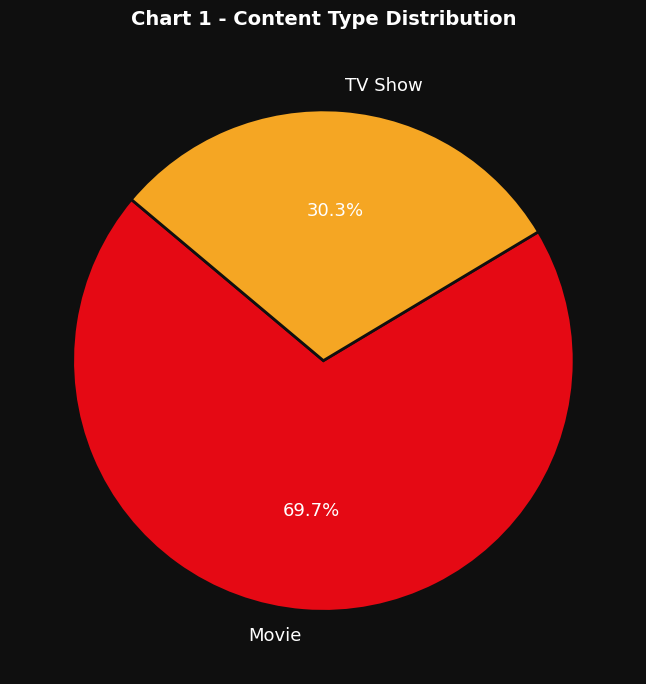

In [23]:
fig, ax = plt.subplots(figsize=(7, 7), facecolor='#0f0f0f')
type_counts = df['type'].value_counts()
ax.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=[NETFLIX_RED, '#F5A623'],
    startangle=140,
    wedgeprops=dict(edgecolor='#0f0f0f', linewidth=2),
    textprops=dict(color='white', fontsize=13)
)
ax.set_title('Chart 1 - Content Type Distribution', fontsize=14, fontweight='bold', color='white', pad=16)
plt.tight_layout()
plt.show()

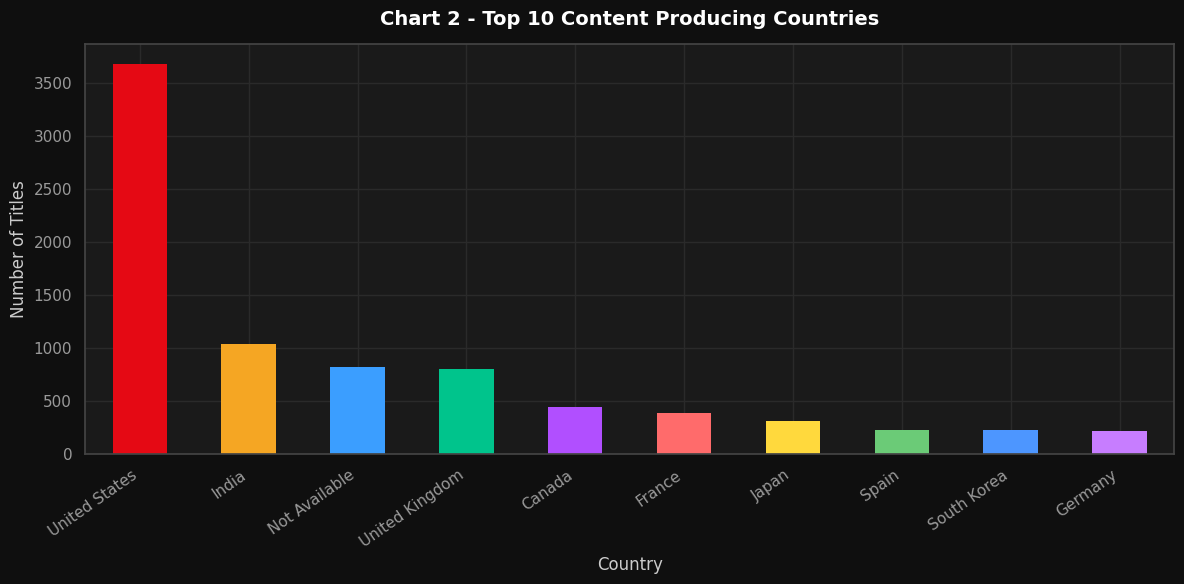

In [24]:
fig, ax = plt.subplots(figsize=(12, 6), facecolor='#0f0f0f')
colors = ['#E50914','#F5A623','#3B9EFF','#00C48C','#B14FFF','#FF6B6B','#FFD93D','#6BCB77','#4D96FF','#C77DFF']
top_countries.plot(kind='bar', ax=ax, color=colors, edgecolor='none')
ax.set_title('Chart 2 - Top 10 Content Producing Countries', fontsize=14, fontweight='bold', color='white', pad=14)
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.set_xticklabels(top_countries.index, rotation=35, ha='right')
plt.tight_layout()
plt.show()

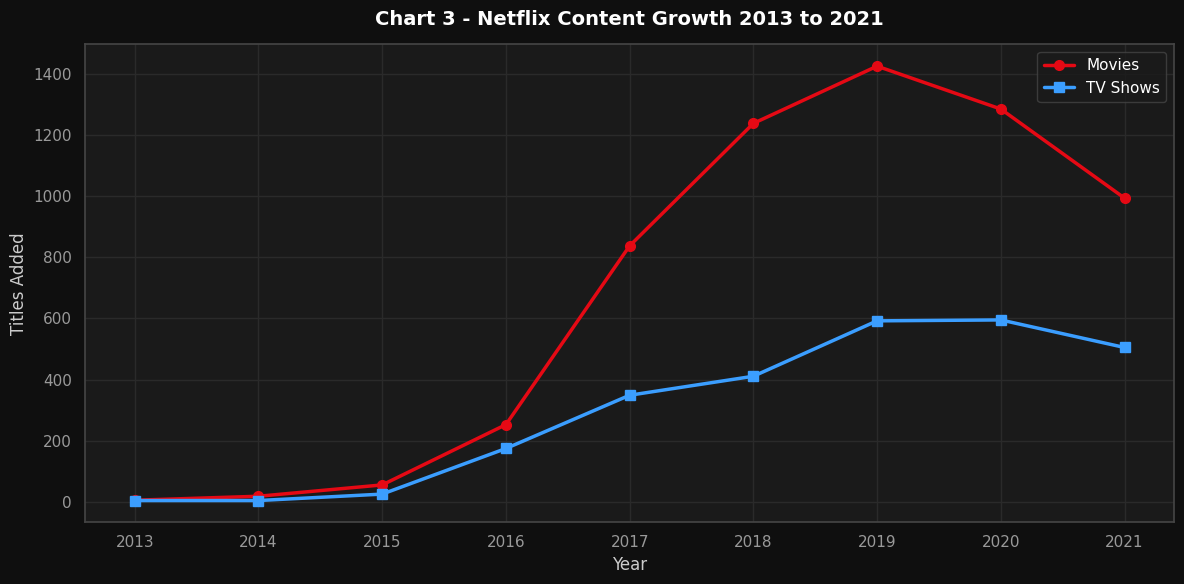

In [25]:
fig, ax = plt.subplots(figsize=(12, 6), facecolor='#0f0f0f')
by_year_f = by_year.loc[2013:2021]
ax.plot(by_year_f.index, by_year_f['Movie'], marker='o', color=NETFLIX_RED, linewidth=2.5, markersize=7, label='Movies')
ax.plot(by_year_f.index, by_year_f['TV Show'], marker='s', color='#3B9EFF', linewidth=2.5, markersize=7, label='TV Shows')
ax.set_title('Chart 3 - Netflix Content Growth 2013 to 2021', fontsize=14, fontweight='bold', color='white', pad=14)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Titles Added', fontsize=12)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

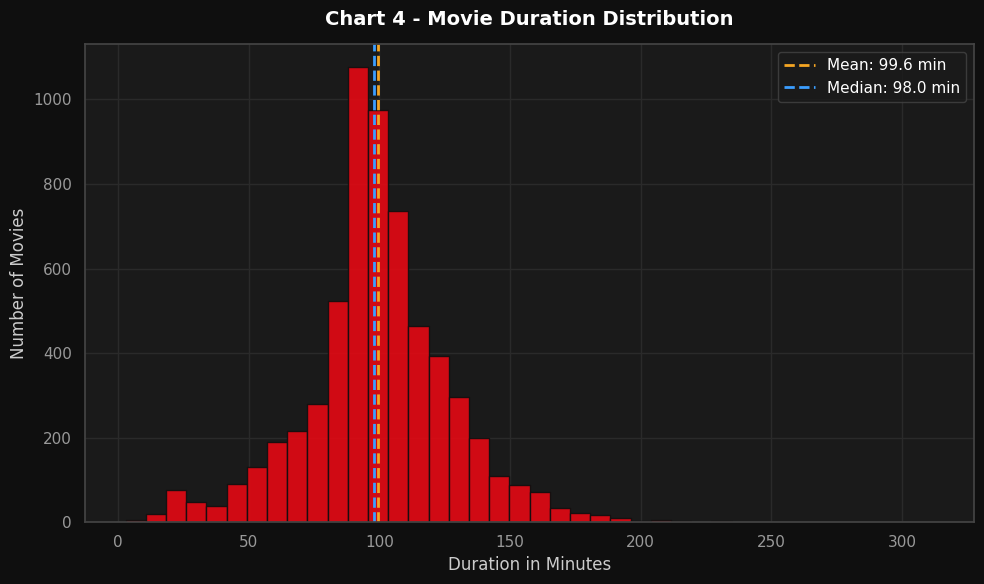

In [26]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#0f0f0f')
ax.hist(movies['duration_value'].dropna(), bins=40, color=NETFLIX_RED, edgecolor='#0f0f0f', alpha=0.9)
ax.axvline(movies['duration_value'].mean(), color='#F5A623', linestyle='--', linewidth=2, label=f"Mean: {movies['duration_value'].mean():.1f} min")
ax.axvline(movies['duration_value'].median(), color='#3B9EFF', linestyle='--', linewidth=2, label=f"Median: {movies['duration_value'].median():.1f} min")
ax.set_title('Chart 4 - Movie Duration Distribution', fontsize=14, fontweight='bold', color='white', pad=14)
ax.set_xlabel('Duration in Minutes', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

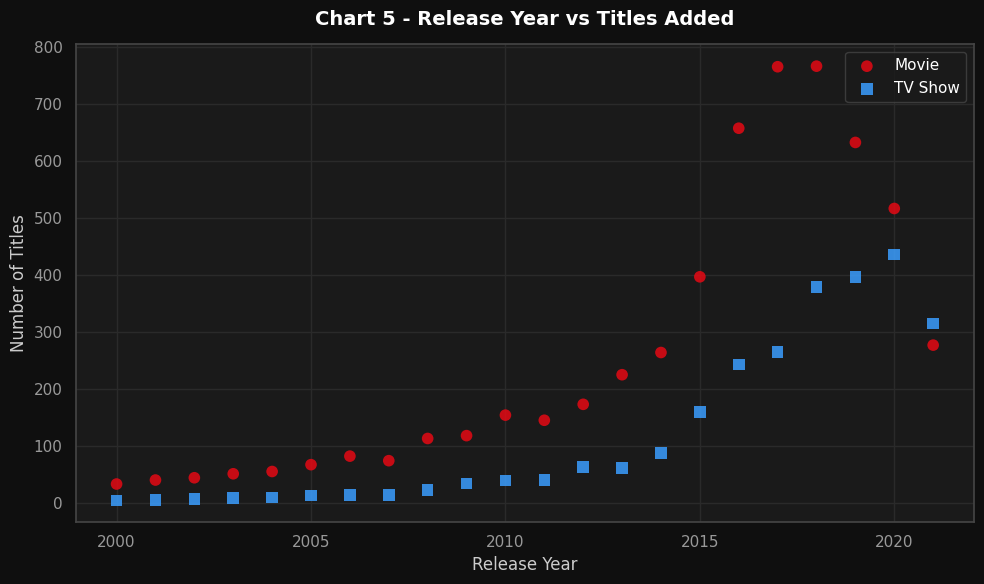

In [27]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#0f0f0f')
scatter_data = df.groupby(['release_year', 'type']).size().reset_index(name='count')
scatter_data = scatter_data[scatter_data['release_year'] >= 2000]
for ctype, color, marker in [('Movie', NETFLIX_RED, 'o'), ('TV Show', '#3B9EFF', 's')]:
    sub = scatter_data[scatter_data['type'] == ctype]
    ax.scatter(sub['release_year'], sub['count'], color=color, label=ctype, alpha=0.85, s=70, marker=marker, edgecolors='none')
ax.set_title('Chart 5 - Release Year vs Titles Added', fontsize=14, fontweight='bold', color='white', pad=14)
ax.set_xlabel('Release Year', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

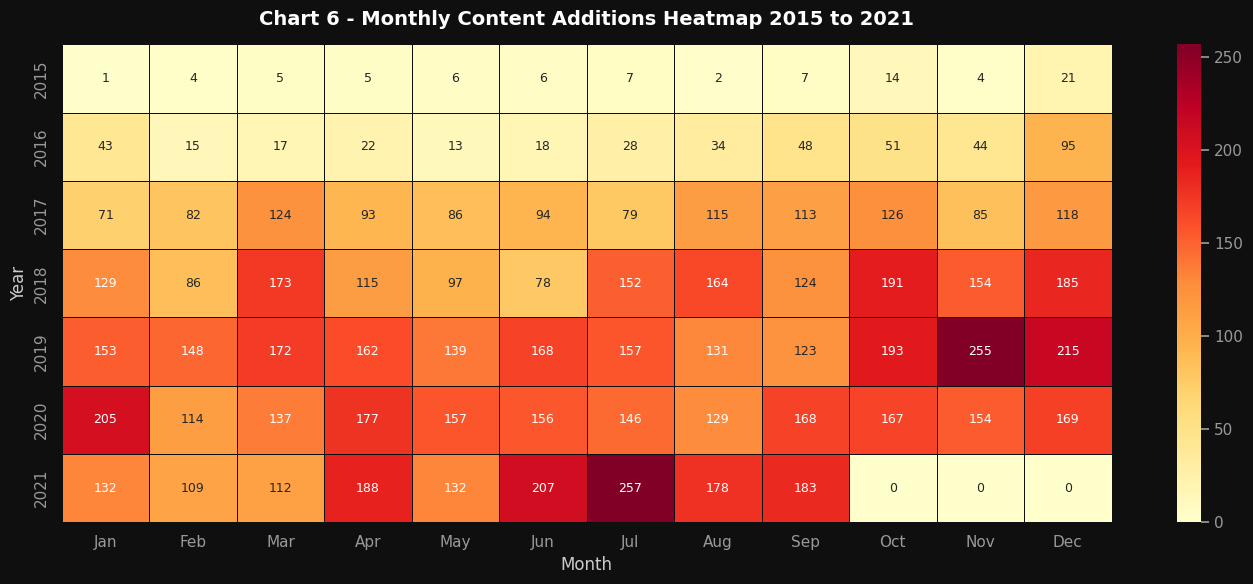

In [28]:
fig, ax = plt.subplots(figsize=(14, 6), facecolor='#0f0f0f')
heatmap_data = df[df['year_added'].between(2015, 2021)].groupby(['year_added', 'month_added']).size().unstack(fill_value=0)
heatmap_data.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sns.heatmap(heatmap_data, ax=ax, cmap='YlOrRd', linewidths=0.5, linecolor='#0f0f0f', annot=True, fmt='d', annot_kws={'size': 9})
ax.set_title('Chart 6 - Monthly Content Additions Heatmap 2015 to 2021', fontsize=14, fontweight='bold', color='white', pad=14)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

## Step 5 - Business Insights Report

### Insight 1 - Movies Dominate But TV Shows Drive Retention
Ref: Chart 1 Pie Chart

Movies are 69.6 percent of catalog but TV shows generate longer watch sessions and lower churn. Netflix should shift ratio from 70/30 to 60/40.

---

### Insight 2 - US Content Monopoly Is a Strategic Risk
Ref: Chart 2 Bar Chart

US accounts for 41.9 percent of all content. India and Korea deliver high global engagement. Co-productions with these markets give the best international ROI.

---

### Insight 3 - 2021 Content Slowdown Is a Warning Signal
Ref: Chart 3 Line Chart

Additions dropped 13.6 percent in 2021 after peaking in 2020. Netflix needs an 18-month forward production pipeline as a buffer.

---

### Insight 4 - Family Content Is Critically Underserved
Ref: Q5 Rating Analysis

TV-MA and TV-14 together make 60.9 percent of catalog. Family ratings are only 6.8 percent. Family accounts churn 40 percent less which directly reduces acquisition cost.

---

### Insight 5 - January and July Are Peak Addition Windows
Ref: Chart 6 Heatmap

Content spikes in January and July matching viewing demand surges. Marquee releases in these months maximize new subscriber acquisition.